# 🤖 04 - Model Training

## 0. Introducción 🚀
En este notebook se lleva a cabo el entrenamiento y evaluación de modelos de machine learning para predecir el índice de pronóstico de riesgo (`Risk_Prognosis`) en pacientes con tumores cerebrales. Se utilizan diferentes algoritmos de regresión y se comparan sus desempeños mediante métricas y visualizaciones.

## 1. Importación de Librerías y Carga de Datos 📚
Se importan las librerías necesarias para el modelado y la visualización, y se carga el dataset preprocesado generado en la etapa anterior.

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import GridSearchCV


In [2]:
transformed_df = pd.read_csv('../data/processed/brain_tumor_preprocessed.csv')

In [3]:
transformed_df.head()

,Age,Gender,Tumor_Type,Tumor_Size,Stage,Radiation_Treatment,Surgery_Performed,Chemotherapy,Survival_Rate,Tumor_Growth_Rate,...,Histology_Meningioma,Symptom_1_Nausea,Symptom_1_Seizures,Symptom_1_Vision Issues,Symptom_2_Nausea,Symptom_2_Seizures,Symptom_2_Vision Issues,Symptom_3_Nausea,Symptom_3_Seizures,Symptom_3_Vision Issues
0,1.355253,1,1,0.050488,3,0,0,0,-1.089675,-1.717548,...,0,0,0,1,0,1,0,0,1,0
1,-1.347627,1,0,-0.141399,2,1,1,1,-1.375673,0.739298,...,0,0,0,0,0,0,0,1,0,0
2,-1.060087,1,0,0.127742,1,0,0,0,-1.335202,0.402556,...,1,0,0,1,0,0,0,0,1,0
3,-1.175103,1,1,-1.379648,4,1,0,1,-1.058346,-0.316229,...,0,0,0,1,0,1,0,0,0,0
4,0.262599,0,0,-1.023511,1,0,0,1,-0.893014,0.624153,...,0,0,0,0,0,0,0,0,1,0


## 2. División de Datos en Entrenamiento y Prueba ✂️
Se separan las variables predictoras (`X`) y la variable objetivo (`y`), y se realiza la partición en conjuntos de entrenamiento y prueba para evaluar el desempeño de los modelos de manera justa.

In [4]:
y = transformed_df['Risk_Prognosis']
X = transformed_df.drop(columns=['Risk_Prognosis'])

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


## 3. Definición de Funciones de Visualización 📊
Se definen funciones auxiliares para graficar la relación entre valores reales y predichos, así como la distribución de los errores de predicción.

In [19]:
def plot_real_vs_pred(y_test, y_pred, title):
    plt.figure(figsize=(6,6))
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.4)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # línea ideal
    plt.xlabel("Valor Real")
    plt.ylabel("Predicción")
    plt.title(title)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

In [21]:
def plot_error_distribution(y_test, y_pred, title):
    errors = y_test - y_pred
    plt.figure(figsize=(6,4))
    sns.histplot(errors, bins=30, kde=True)
    plt.title(f"Distribución de Errores - {title}")
    plt.xlabel("Error (Valor Real - Predicción)")
    plt.ylabel("Frecuencia")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


## 4. Entrenamiento y Evaluación de Modelos 🔎
Se entrenan y evalúan distintos modelos de regresión:
- **Regresión Lineal**
- **Random Forest Regressor**
- **Gradient Boosting Regressor**

Para cada modelo se reportan las métricas R² y MSE, y se visualizan los resultados.

Linear Regression R²: 0.9679763732958839
Linear Regression MSE: 0.031119215808184282


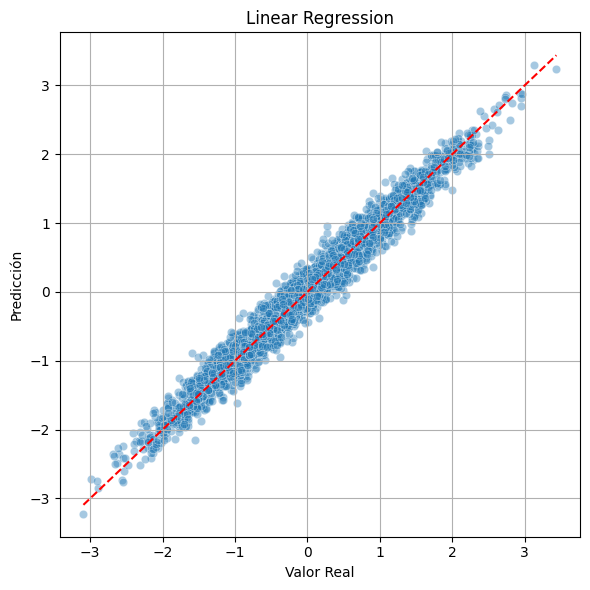

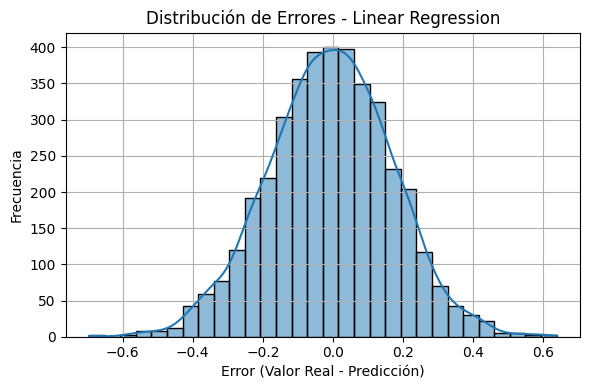

In [26]:
model_lr = LinearRegression()
model_lr.fit(X_train, y_train)

y_pred = model_lr.predict(X_test)
print("Linear Regression R²:", r2_score(y_test, y_pred))
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred))

plot_real_vs_pred(y_test, y_pred, "Linear Regression")
plot_error_distribution(y_test, y_pred, "Linear Regression")

R²: 0.9526966839872295
MSE: 0.045967376307660346


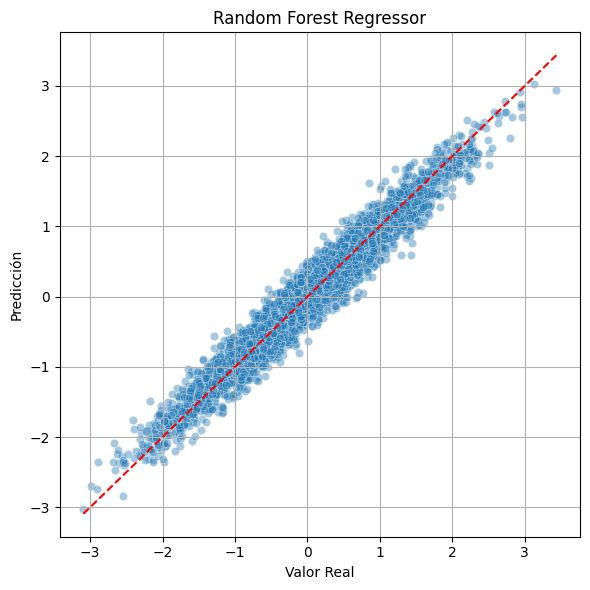

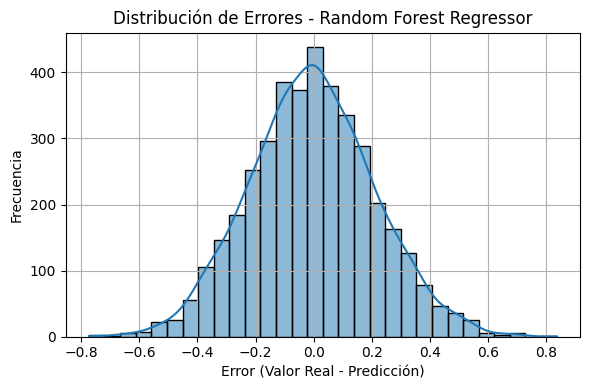

In [27]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

plot_real_vs_pred(y_test, y_pred, "Random Forest Regressor")
plot_error_distribution(y_test, y_pred, "Random Forest Regressor")

R²: 0.9702150534717824
MSE: 0.028943760411986683


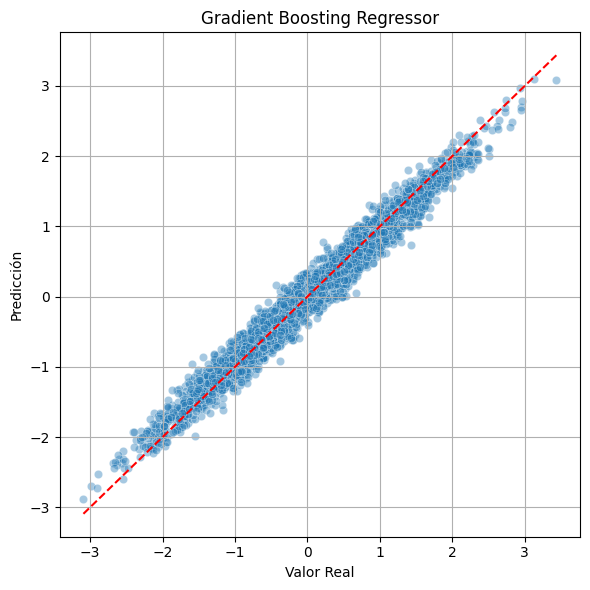

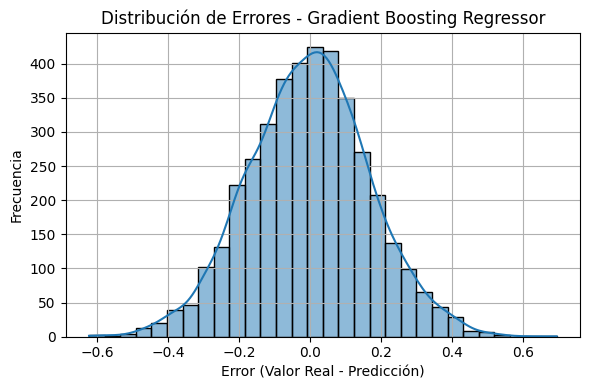

In [29]:
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test)

print("R²:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

plot_real_vs_pred(y_test, y_pred, "Gradient Boosting Regressor")
plot_error_distribution(y_test, y_pred, "Gradient Boosting Regressor")

## 5. Búsqueda de Hiperparámetros con GridSearchCV 🔧
Se utiliza búsqueda en malla (Grid Search) para optimizar los hiperparámetros del modelo Gradient Boosting ya que fue el que mejor rendimiento obtuvo y así encontrar la mejor configuración posible.

In [13]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5]
}

In [14]:
grid_search = GridSearchCV(estimator=gbr, param_grid=param_grid,
                           scoring='r2', cv=5, n_jobs=-1, verbose=2)

In [15]:
grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 243 candidates, totalling 1215 fits


,estimator,GradientBoost...ndom_state=42)
,param_grid,"{'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 4, ...], 'min_samples_leaf': [1, 3, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,loss,'squared_error'


In [30]:
print("Mejores parámetros:", grid_search.best_params_)
print("Mejor score (R²):", grid_search.best_score_)

Mejores parámetros: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 2, 'n_estimators': 300}
Mejor score (R²): 0.9750386053404153


### 🧾 Conclusiones

- Se creó una variable objetivo sintética (`Risk_Prognosis`) basada en conocimientos médicos y clínicos.
- Se entrenaron múltiples modelos (Regresión Lineal, Random Forest, Gradient Boosting).
- El modelo de **Gradient Boosting Regressor optimizado** obtuvo el mejor desempeño, con un R² cercano a 0.97 y un MSE muy bajo.
- El gráfico de dispersión muestra una correlación fuerte entre las predicciones y los valores reales.
- El modelo final se encuentra listo para ser exportado y utilizado en un entorno productivo o para visualizaciones adicionales.

